 Identify technology-sector freshers (first-year employees) who are likely to leave the company, helping HR reduce early attrition.

In [2]:
#  Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

#  Step 2: Load Dataset
df = pd.read_csv('//content//sample_data//test.csv')
print("Original shape:", df.shape)
df.head()



Original shape: (14900, 24)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


In [ ]:
#  Drop irrelevant columns
df.drop(columns=['Employee ID'], inplace=True, errors='ignore')

#  Filter freshers
df_freshers = df[df['Years at Company'] <= 1].copy()

#  Filter tech roles based on keywords
df_freshers = df_freshers[df_freshers['Job Role'] == 'Technology']

print("Filtered dataset (Tech + Freshers):", df_freshers.shape)
df_freshers['Attrition'].value_counts()


Filtered dataset (Tech + Freshers): (142, 23)


,count
Attrition,
Left,79
Stayed,63


In [ ]:
# Encode target variable
df_freshers['Attrition'] = df_freshers['Attrition'].map({'Left': 1, 'Stayed': 0})

# Check for missing values
df_freshers.isnull().sum()


,0
Age,0
Gender,0
Years at Company,0
Job Role,0
Monthly Income,0
Work-Life Balance,0
Job Satisfaction,0
Performance Rating,0
Number of Promotions,0
Overtime,0


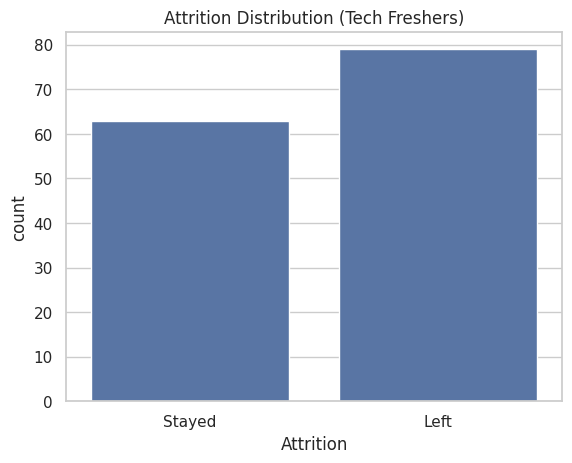

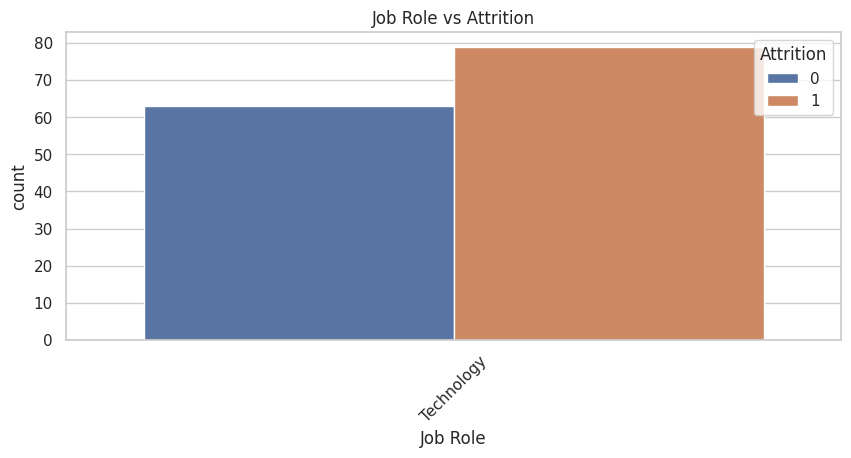

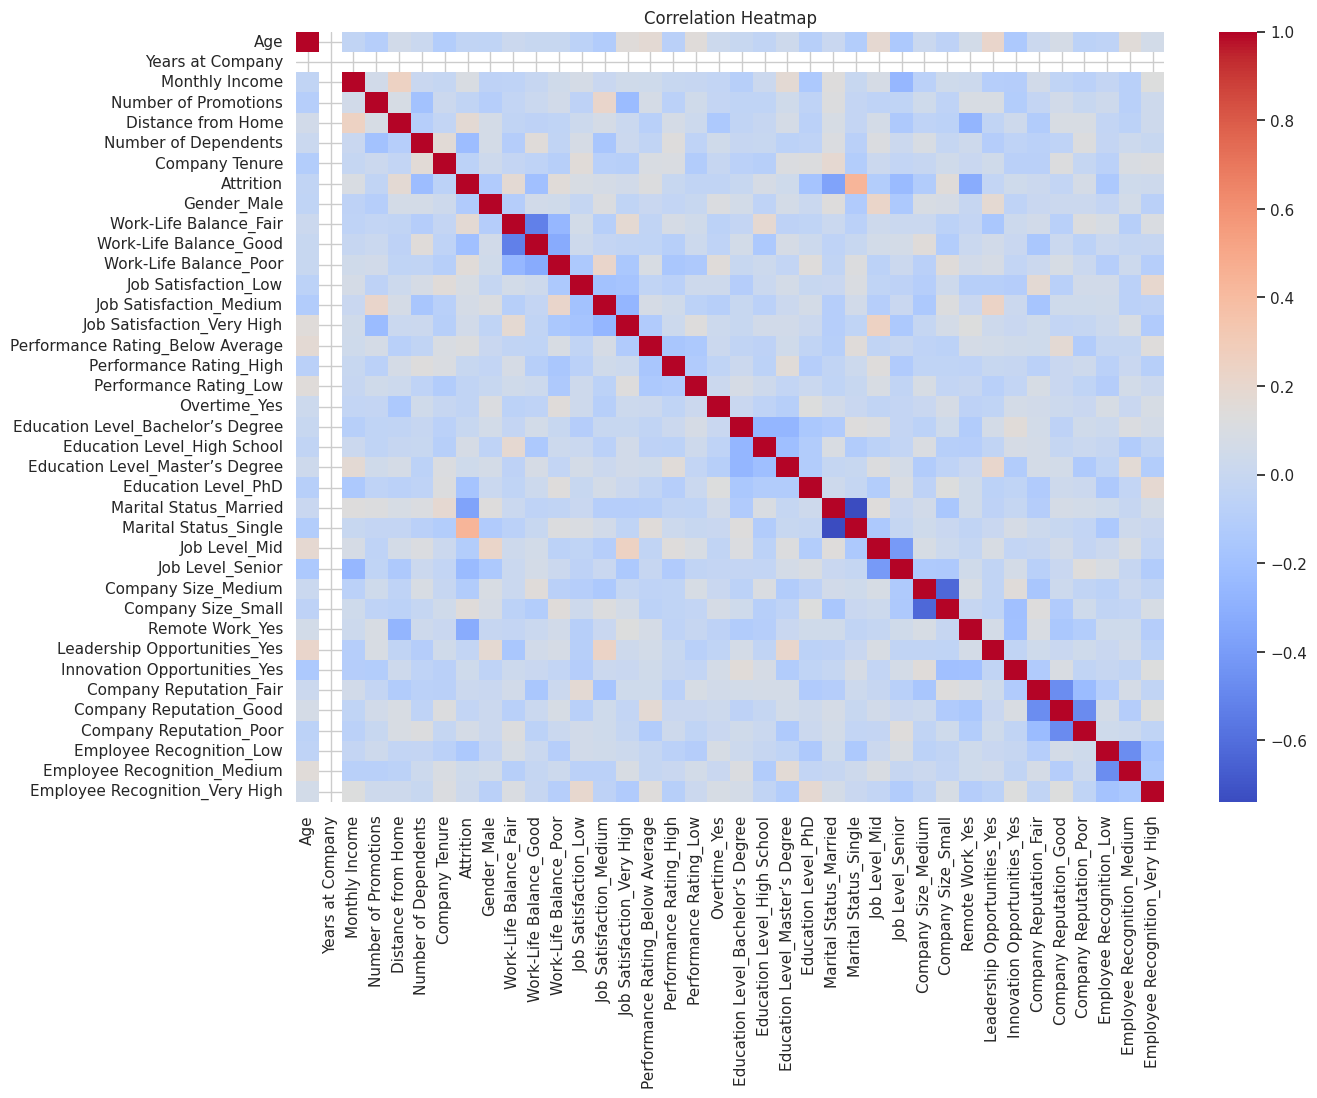

In [ ]:
# Attrition count
sns.countplot(x='Attrition', data=df_freshers)
plt.title("Attrition Distribution (Tech Freshers)")
plt.xticks([0,1], ['Stayed', 'Left'])
plt.show()

# Job Role vs Attrition
plt.figure(figsize=(10,4))
sns.countplot(data=df_freshers, x='Job Role', hue='Attrition')
plt.xticks(rotation=45)
plt.title("Job Role vs Attrition")
plt.show()

# Correlation Heatmap
df_encoded_corr = pd.get_dummies(df_freshers, drop_first=True)
plt.figure(figsize=(14,10))
sns.heatmap(df_encoded_corr.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# One-hot encode categoricals
df_encoded = pd.get_dummies(df_freshers, drop_first=True)

# Features and Target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# Balance classes with upsampling
df_majority = df_encoded[df_encoded.Attrition == 0]
df_minority = df_encoded[df_encoded.Attrition == 1]

df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
df_balanced = pd.concat([df_majority, df_minority_upsampled])

X = df_balanced.drop('Attrition', axis=1)
y = df_balanced['Attrition']

# Train/Test split + Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
# Data preprocessing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=1)  # For binary classification, max components = 1
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda  = lda.transform(X_test_scaled)

# Model training with LDA-transformed data
model = RandomForestClassifier(random_state=42)
model.fit(X_train_lda, y_train)

# Evaluation
y_pred = model.predict(X_test_lda)
print("LDA + RandomForest Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


LDA + RandomForest Accuracy: 0.9230769230769231
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       0.85      1.00      0.92        11

    accuracy                           0.92        26
   macro avg       0.92      0.93      0.92        26
weighted avg       0.93      0.92      0.92        26

